In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")

Matplotlib is building the font cache; this may take a moment.


In [2]:
players   = pd.read_csv("../data/processed/players_master.csv")
results   = pd.read_csv("../data/raw/kaggle/results.csv")
understat = pd.read_csv("../data/raw/understat_player_stats.csv")

print("players:",   players.shape)
print("results:",   results.shape)
print("understat:", understat.shape)

players: (1248, 25)
results: (49477, 9)
understat: (3245, 19)


In [3]:
results["date"] = pd.to_datetime(results["date"])
print(results["tournament"].value_counts().head(15))

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Name: count, dtype: int64


Cant train the model on all these matches equally, the friendlies will have less weightage compared to WC etc

In [4]:
wc = results[results["tournament"]=="FIFA World Cup"].copy()
wc["total_goals"] = wc["home_score"] + wc["away_score"]
print(f"WC matches: {len(wc)}")
print(f"Date range: {wc['date'].min().year} → {wc['date'].max().year}")
print(f"Avg goals per game: {wc['total_goals'].mean():.2f}")
print(f"Draw rate: {(wc['home_score'] == wc['away_score']).mean()*100:.1f}%")

WC matches: 1036
Date range: 1930 → 2026
Avg goals per game: 2.82
Draw rate: 21.4%


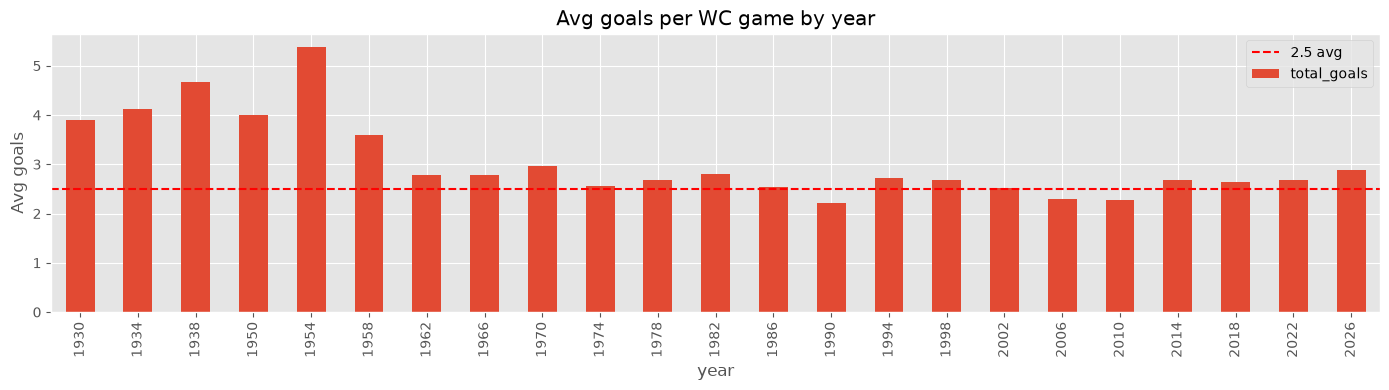

In [5]:
wc["year"] = wc["date"].dt.year
wc.groupby("year")["total_goals"].mean().plot(
    kind="bar", figsize=(14, 4), title="Avg goals per WC game by year"
)
plt.axhline(2.5, color="red", linestyle="--", label="2.5 avg")
plt.ylabel("Avg goals")
plt.legend()
plt.tight_layout()
plt.show()

Pre 1962 is completely different, avg goals stabilise after that. filtering data from 1966 onwards to train the model

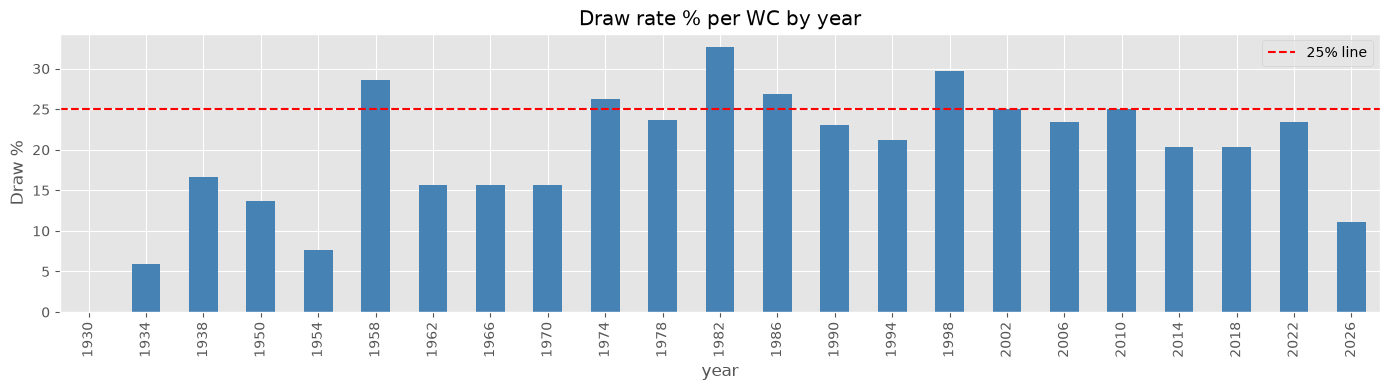

In [6]:
wc.groupby("year").apply(
    lambda g: (g["home_score"] == g["away_score"]).mean() * 100
).plot(kind="bar", figsize=(14, 4), title="Draw rate % per WC by year", color="steelblue")
plt.axhline(25, color="red", linestyle="--", label="25% line")
plt.ylabel("Draw %")
plt.legend()
plt.tight_layout()
plt.show()

Target 22-25% as draw rate. since most years cluster around 20-25% draws

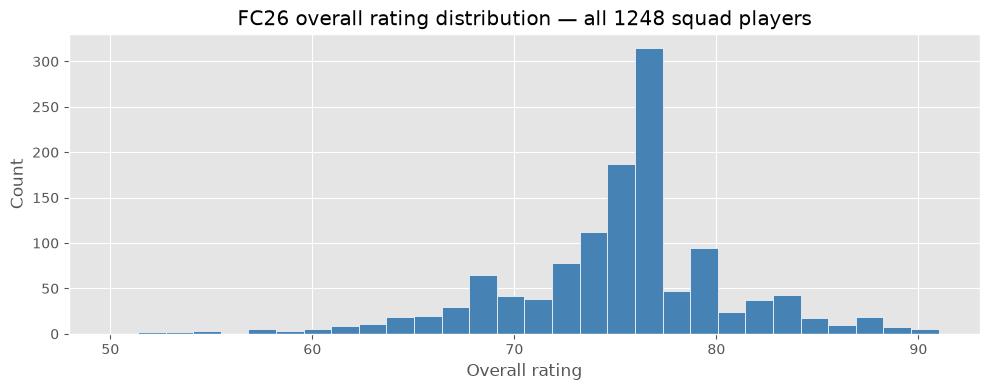

count    1248.000000
mean       75.026442
std         5.526645
min        50.000000
25%        73.000000
50%        75.000000
75%        77.000000
max        91.000000
Name: overall, dtype: float64


In [7]:
import matplotlib.pyplot as plt

players["overall"] = pd.to_numeric(players["overall"], errors="coerce")

players["overall"].hist(bins=30, figsize=(10, 4), color="steelblue", edgecolor="white")
plt.title("FC26 overall rating distribution — all 1248 squad players")
plt.xlabel("Overall rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(players["overall"].describe())

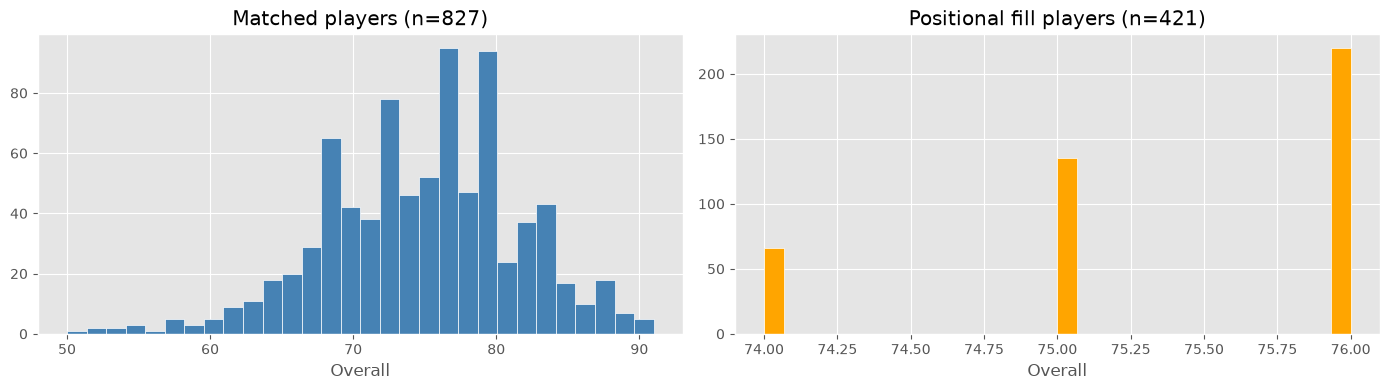

In [8]:
matched = players[players["match_type"] != "positional_fill"]["overall"]
filled  = players[players["match_type"] == "positional_fill"]["overall"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=False)

matched.hist(bins=30, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title(f"Matched players (n={len(matched)})")
axes[0].set_xlabel("Overall")

filled.hist(bins=30, ax=axes[1], color="orange", edgecolor="white")
axes[1].set_title(f"Positional fill players (n={len(filled)})")
axes[1].set_xlabel("Overall")

plt.tight_layout()
plt.show()

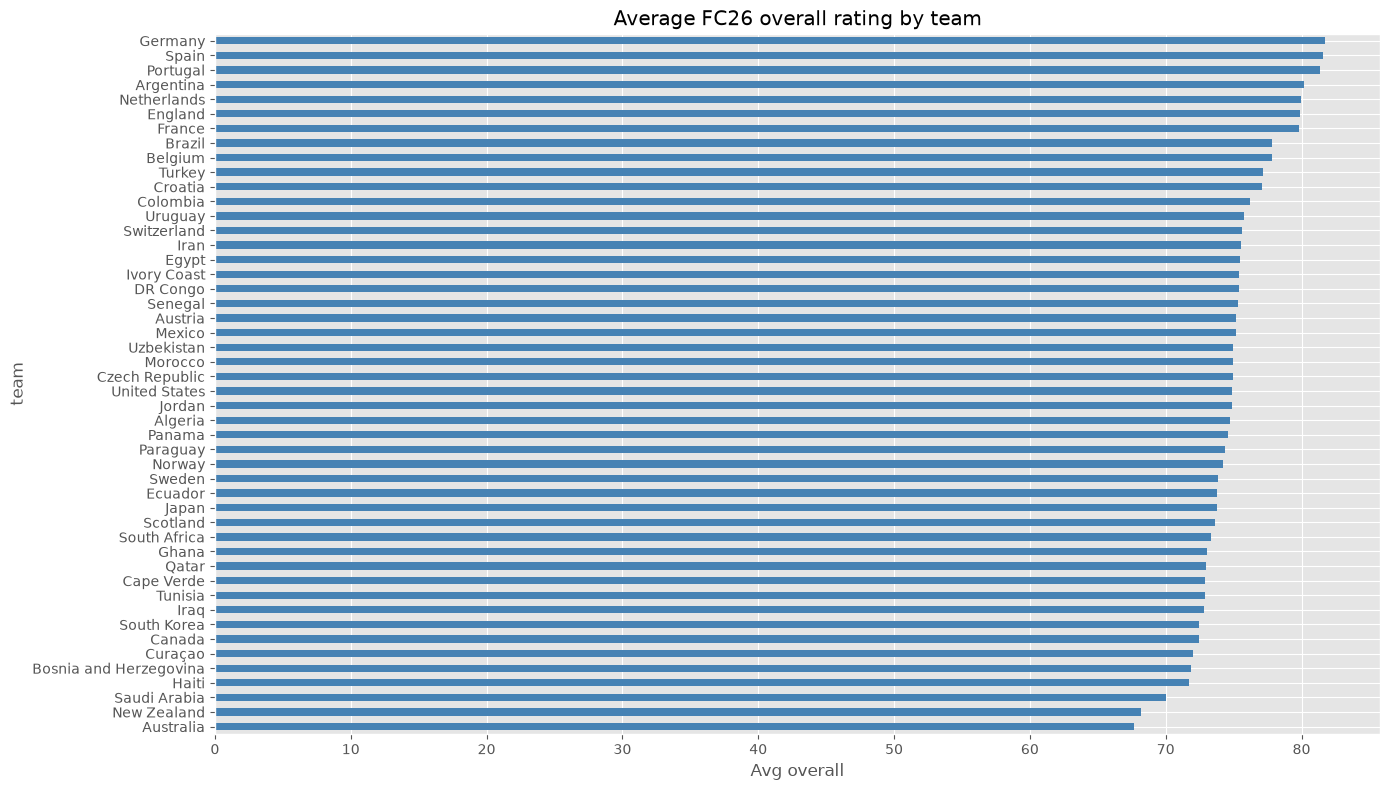

In [9]:
team_avg = (
    players.groupby("team")["overall"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(14, 8))
team_avg.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Average FC26 overall rating by team")
ax.set_xlabel("Avg overall")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
players[players["team"] == "Australia"][["name", "broad_pos", "overall", "match_type"]].sort_values("overall", ascending=False)

,name,broad_pos,overall,match_type
312,Mathew Ryan,GK,78.0,fuzzy_nat_long
333,Jackson Irvine,MID,76.0,positional_fill
317,Jason Geria,DEF,75.0,positional_fill
313,Miloš Degenek,DEF,75.0,positional_fill
330,Harry Souttar,DEF,73.0,fuzzy_nat_short
332,Cameron Burgess,DEF,73.0,fuzzy_nat_long
325,Cammy Devlin,MID,71.0,fuzzy_nat_short
314,Alessandro Circati,DEF,71.0,exact_long
318,Mathew Leckie,ATT,70.0,fuzzy_nat_long
324,Aiden O'Neill,MID,70.0,fuzzy_nat_short


 ISSUE: Jordan Bos matched to wrong player (overall 50)
 Paul Okon-Engstler, Lucas Herrington also suspiciously low
 Fix: manually override these in 04_build_player_master.py before Phase 3

In [11]:
print(understat["league"].value_counts())
print(f"\nxG range: {understat['xG'].min():.2f} → {understat['xG'].max():.2f}")
print(f"Players with xG > 10: {(understat['xG'] > 10).sum()}")

league
ESP-La Liga           600
ITA-Serie A           586
FRA-Ligue 1           553
ENG-Premier League    537
GER-Bundesliga        499
RUS-Premier League    470
Name: count, dtype: int64

xG range: 0.00 → 29.58
Players with xG > 10: 91


In [12]:
print(understat[["player_name", "games", "xG", "league"]].sort_values("xG", ascending=False).head(10))

               player_name  games         xG              league
1137            Harry Kane     31  29.579986      GER-Bundesliga
0           Erling Haaland     35  28.795336  ENG-Premier League
537   Kylian Mbappe-Lottin     31  25.796529         ESP-La Liga
1                   Thiago     38  24.689773  ENG-Premier League
538           Vedat Muriqi     37  21.630785         ESP-La Liga
1139       Serhou Guirassy     33  19.911182      GER-Bundesliga
1140         Patrik Schick     28  19.421328      GER-Bundesliga
539           Ante Budimir     37  19.191765         ESP-La Liga
1138           Deniz Undav     29  19.057547      GER-Bundesliga
3            Ollie Watkins     37  18.827726  ENG-Premier League



ISSUE: Understat has some clearly wrong entries e.g "Thiago" at Brentford 
with 24.69 xG — likely a data error in Understat source
These outliers will need filtering before using xG in team vectors

In [13]:
squad_names = set(players["name"].str.lower().str.strip())
understat_names = set(understat["player_name"].str.lower().str.strip())

overlap = squad_names & understat_names
print(f"Direct name matches: {len(overlap)} / {len(squad_names)}")
print(f"\nSample matched: {list(overlap)[:10]}")

Direct name matches: 410 / 1247

Sample matched: ['daniel svensson', 'michael olise', 'ibrahim mbaye', 'elisha owusu', 'julian ryerson', 'erling haaland', 'ibrahima konaté', 'joshua kimmich', 'mattias svanberg', 'simon adingra']


410 squad players match Understat directly by name
More recoverable via fuzzy — handle in 05_build_team_vectors.py
Russian Premier League rows mostly useless — filter to EU5 leagues only

Merged rows: 426


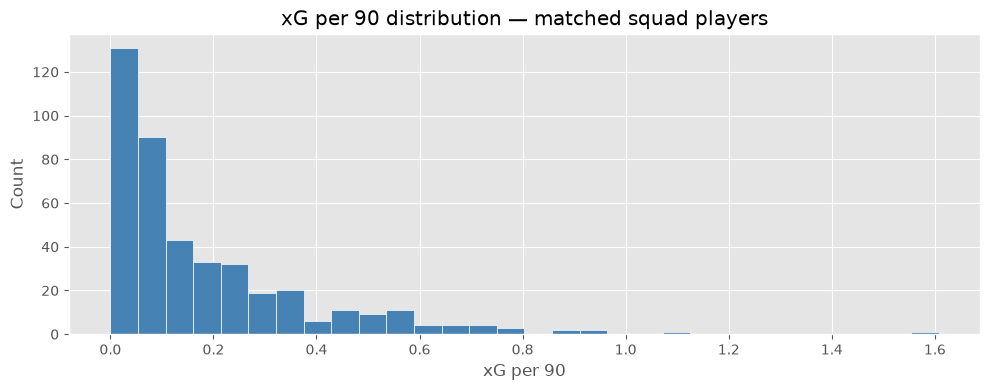

In [14]:
understat["name_lower"] = understat["player_name"].str.lower().str.strip()
players["name_lower"] = players["name"].str.lower().str.strip()

matched_understat = players.merge(
    understat, on="name_lower", how="inner"
)

print(f"Merged rows: {len(matched_understat)}")

matched_understat["xG_per90"] = matched_understat["xG"] / (matched_understat["time"] / 90)

matched_understat["xG_per90"].hist(bins=30, figsize=(10,4), color="steelblue", edgecolor="white")
plt.title("xG per 90 distribution — matched squad players")
plt.xlabel("xG per 90")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

xG/90 distribution is right-skewed as expected
Outliers at 1.2+ are likely low-minute players with inflated per-90 rates
Filter: minimum 200 minutes or 5 games before using xG/90 in team vectors

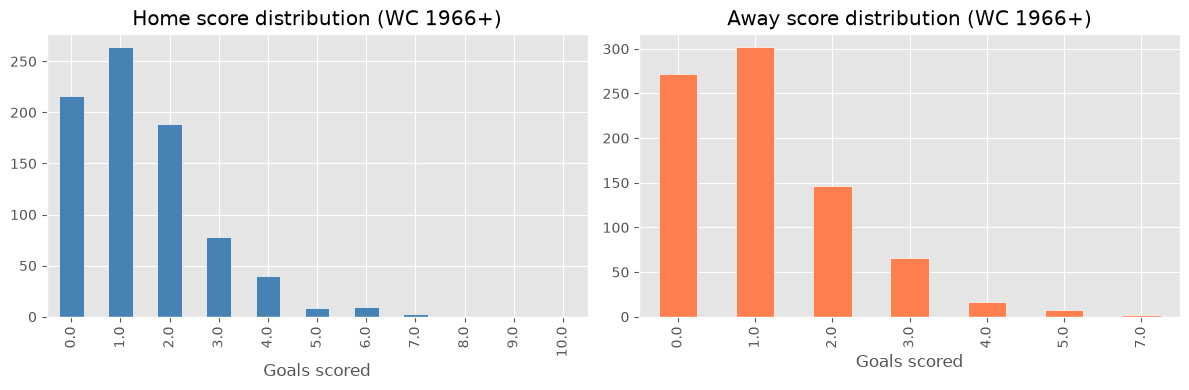

In [15]:
modern_wc = wc[wc["year"] >= 1966].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

modern_wc["home_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Home score distribution (WC 1966+)")
axes[0].set_xlabel("Goals scored")

modern_wc["away_score"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="coral", edgecolor="white"
)
axes[1].set_title("Away score distribution (WC 1966+)")
axes[1].set_xlabel("Goals scored")

plt.tight_layout()
plt.show()

In [16]:
print("=== EDA SUMMARY ===")
print(f"\nResults dataset: {len(results)} matches, {results['date'].dt.year.min()}–{results['date'].dt.year.max()}")
print(f"WC matches (1966+): {len(modern_wc)}")
print(f"Modern WC avg goals/game: {modern_wc['total_goals'].mean():.2f}")
print(f"Modern WC draw rate: {(modern_wc['home_score'] == modern_wc['away_score']).mean()*100:.1f}%")
print(f"\nPlayers: {len(players)} total, {(players['match_type'] != 'positional_fill').sum()} with real FC26 data")
print(f"Understat squad coverage: 410 / 1247 direct matches")

=== EDA SUMMARY ===

Results dataset: 49477 matches, 1872–2026
WC matches (1966+): 868
Modern WC avg goals/game: 2.58
Modern WC draw rate: 22.8%

Players: 1248 total, 827 with real FC26 data
Understat squad coverage: 410 / 1247 direct matches


## EDA Conclusions

### Results dataset
- Filter to 1966+ for model training — pre-1966 football is a different era
- Modern WC averages: 2.58 goals/game, 22.8% draw rate — use these as calibration targets for Dixon-Coles
- Score distributions are Poisson-like but 0s are slightly overrepresented vs pure Poisson — justifies using Dixon-Coles over raw Poisson

### Players dataset
- 827/1248 players have real FC26 data, 421 on positional fills (74-76 overall)
- Fill-heavy teams (Jordan, Iran, Egypt, Uzbekistan) will have artificially homogeneous vectors — predictions for these teams will be less precise
- Several bad fuzzy matches identified: Jordan Bos (Australia, overall 50), Paul Okon-Engstler (52), Lucas Herrington (59) — fix in 04_build_player_master.py before Phase 3

### Understat dataset
- 2024/25 season data — good recency
- 410/1247 direct squad name matches — more recoverable via fuzzy in Phase 3
- Filter minimum 200 minutes before using xG/90 — low minute players have inflated rates
- Russian Premier League rows (470) mostly useless — filter to EU5 only
- One clear data error: "Thiago" at Brentford with 24.69 xG — filter outliers above 1.0 xG/90

### Issues to fix before Phase 3
1. Bad fuzzy matches in players_master.csv — manually override Australia low ratings
2. Understat Russian league rows — drop before merging
3. xG/90 minimum minutes filter — 200 min threshold
4. Understat name matching — run fuzzy join to recover more than 410 players